# Signformer — PHOENIX-2014T (Sign Language Recognition)

Modular runner notebook. All logic lives in `.py` modules inside `main/`:
- `config.py` — device, paths, YAML config loading
- `main/data.py` — dataset loading (gzipped pickles)
- `main/model.py` — Signformer (Conformer encoder + Transformer decoder)
- `main/training.py` — TrainManager with periodic checkpoint resume
- `main/prediction.py` — validation & test evaluation
- `main/metrics.py` — WER, BLEU, chrF, ROUGE
- `main/helpers.py` — utilities, config loading, training curves

## 0 — Imports and setup

In [1]:
import sys, os, subprocess
from pathlib import Path

# ensure working directory is the Signformer folder
SIGNFORMER_DIR = Path(".").resolve()
assert (SIGNFORMER_DIR / "main" / "training.py").exists(), \
    "ERROR: run this notebook from the Signformer/ folder"
if str(SIGNFORMER_DIR) not in sys.path:
    sys.path.insert(0, str(SIGNFORMER_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt

from config import DEVICE, USE_CUDA, set_seed, load_cfg, print_cfg
from main.helpers import load_config, set_seed as _set_seed
from main.data import load_data, make_data_iter
from main.model import build_model
from main.training import TrainManager, train
from main.prediction import test as run_test

print(f"device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device: cuda
PyTorch: 2.6.0+cu124
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB


## 1 — Load data

In [2]:
CFG = load_cfg("configs/sign.yaml")
print_cfg(CFG)

print("\nLoading data...")
train_data, dev_data, test_data, gls_vocab, txt_vocab = load_data(CFG["data"])

print(f"Train : {len(train_data)} samples")
print(f"Dev   : {len(dev_data)} samples")
print(f"Test  : {len(test_data)} samples")
print(f"Gloss vocab: {len(gls_vocab)} tokens")
print(f"Text  vocab: {len(txt_vocab)} tokens")

  batch_size      : 32
  optimizer       : sophiag
  learning_rate   : 0.0003123245797199696
  weight_decay    : 0.004984037047442559
  epochs          : 1000
  early_stop      : 10 epochs
  hidden_size     : 256
  encoder_layers  : 3
  encoder_dropout : 0.2401672517614813
  eval_metric     : wer
  recognition_wt  : 1.0
  translation_wt  : 0.0

Loading data...
Train : 7094 samples
Dev   : 519 samples
Test  : 642 samples
Gloss vocab: 1087 tokens
Text  vocab: 2888 tokens


## 2 — Instantiate model

In [3]:
do_recognition = CFG["training"].get("recognition_loss_weight", 1.0) > 0.0
do_translation = CFG["training"].get("translation_loss_weight", 1.0) > 0.0
multimodal = CFG["data"].get("multimodal", 1.0) > 0.0
sgn_dim = (
    sum(CFG["data"]["feature_size"])
    if isinstance(CFG["data"]["feature_size"], list)
    else CFG["data"]["feature_size"]
)

model = build_model(
    cfg=CFG["model"],
    multimodal=multimodal,
    gls_vocab=gls_vocab,
    txt_vocab=txt_vocab,
    sgn_dim=sgn_dim,
    do_recognition=do_recognition,
    do_translation=do_translation,
)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"parameters: {n_params:.2f} M  (trainable: {n_train:.2f} M)")

COPE:  False
parameters: 3.76 M  (trainable: 3.76 M)


## 3 — (Optional) Optuna hyperparameter search


In [4]:
# ============================================================================
# >>> MANUAL KNOB — epochs per Optuna trial (edit this) <<<
#     WER stays flat during the warmup (epoch 0-2), so give each trial enough
#     epochs to get past it and converge. Recommended 30-40.
NUM_EPOCHS_PER_TRIAL = 35
# ============================================================================

USE_OPTUNA = False

if USE_OPTUNA:
    import copy, gc, tempfile, shutil, time as _time, yaml
    try:
        import optuna
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
        import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # --- Optuna config -------------------------------------------------------
    # WER-vs-epoch analysis of the working 33-epoch run:
    #   epoch 0-2  : ~100%  (CTC blank collapse / warmup — configs indistinguishable)
    #   epoch 3-4  : 90->71%  (model unlocks)
    #   epoch 8-11 : 47->44%  (configs already clearly separated)
    #   epoch ~22  : 42.06%   (best; beyond this only decimals change)
    # Each trial runs NUM_EPOCHS_PER_TRIAL past the warmup; early stopping is
    # disabled (patience >= epochs) so no trial is killed during the 100% phase.
    OPTUNA_TRIALS = 6

    # Proven-good values from the baseline config (WER 42.06%):
    #   lr=0.0004, wd=0.003, encoder dropout=0.2
    # Search a SMALL neighbourhood around each.
    LR_RANGE   = (3e-4, 6e-4)     # log-uniform around 4e-4
    WD_RANGE   = (1.5e-3, 6e-3)   # log-uniform around 3e-3
    DROP_RANGE = (0.15, 0.30)     # uniform around 0.2

    print(f'[Optuna] Signformer hyperparameter search')
    print(f'  trials          : {OPTUNA_TRIALS}')
    print(f'  epochs/trial    : {NUM_EPOCHS_PER_TRIAL} (fixed, past the warmup)')
    print(f'  lr              : {LR_RANGE}')
    print(f'  wd              : {WD_RANGE}')
    print(f'  dropout         : {DROP_RANGE}')
    print('=' * 70)

    _optuna_log = []

    def _trial_wer(trial):
        _t0 = _time.time()
        lr   = trial.suggest_float('learning_rate', *LR_RANGE, log=True)
        wd   = trial.suggest_float('weight_decay', *WD_RANGE, log=True)
        drop = trial.suggest_float('encoder_dropout', *DROP_RANGE)

        print(f'\n--- Trial {trial.number + 1}/{OPTUNA_TRIALS} ---')
        print(f'  lr={lr:.6f}  wd={wd:.6f}  drop={drop:.4f}')

        cfg_t = copy.deepcopy(CFG)
        tr = cfg_t['training']
        tr['learning_rate'] = float(lr)
        tr['weight_decay']  = float(wd)
        # fixed epoch budget; patience >= epochs so early stopping never fires
        # during the warmup plateau (where all configs sit at ~100% WER).
        tr['epochs'] = NUM_EPOCHS_PER_TRIAL
        tr['early_stopping_patience'] = NUM_EPOCHS_PER_TRIAL + 1
        tr['overwrite'] = True
        tr['model_dir'] = tempfile.mkdtemp(prefix='optuna_trial_', dir='.')
        cfg_t['model']['encoder']['dropout'] = float(drop)
        cfg_t['model']['encoder']['embeddings']['dropout'] = float(drop)

        _model = build_model(
            cfg=cfg_t['model'], multimodal=multimodal,
            gls_vocab=gls_vocab, txt_vocab=txt_vocab, sgn_dim=sgn_dim,
            do_recognition=do_recognition, do_translation=do_translation,
        )
        trainer = TrainManager(model=_model, config=cfg_t)
        trainer.train_and_validate(train_data=train_data, valid_data=dev_data)
        wer = float(trainer.best_ckpt_score)
        elapsed = _time.time() - _t0

        _optuna_log.append({
            'trial': trial.number + 1, 'wer': wer,
            'lr': lr, 'wd': wd, 'drop': drop, 'time': elapsed,
        })
        print(f'  => Trial {trial.number+1} | best WER = {wer:.2f}% | {elapsed:.0f}s')

        # cleanup trial dir
        try:
            shutil.rmtree(tr['model_dir'])
        except OSError:
            pass

        del trainer, _model; gc.collect(); torch.cuda.empty_cache()
        return wer

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(_trial_wer, n_trials=OPTUNA_TRIALS)

    print('\n' + '=' * 70)
    print('[Optuna] SEARCH COMPLETE')
    for r in sorted(_optuna_log, key=lambda x: x['wer']):
        print(f"  trial {r['trial']:2d} | WER {r['wer']:7.2f} | lr={r['lr']:.6f} wd={r['wd']:.6f} drop={r['drop']:.4f} | {r['time']:.0f}s")
    print(f'\nbest WER: {study.best_value:.2f}% | params: {study.best_params}')

    # write best params back to YAML
    from config import save_cfg
    CFG['training']['learning_rate'] = float(study.best_params['learning_rate'])
    CFG['training']['weight_decay']  = float(study.best_params['weight_decay'])
    CFG['model']['encoder']['dropout'] = float(study.best_params['encoder_dropout'])
    CFG['model']['encoder']['embeddings']['dropout'] = float(study.best_params['encoder_dropout'])
    save_cfg(CFG)
    print('configs/sign.yaml updated with Optuna best.')
else:
    print('Optuna search disabled — using current YAML values.')

# always rebuild model with fresh weights
model = build_model(
    cfg=CFG["model"], multimodal=multimodal,
    gls_vocab=gls_vocab, txt_vocab=txt_vocab, sgn_dim=sgn_dim,
    do_recognition=do_recognition, do_translation=do_translation,
)
print(f"fresh model: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M params")

Optuna search disabled — using current YAML values.
COPE:  False
fresh model: 3.76 M params


## 4 — Train (with resume checkpoints)

Periodic checkpoints (`resume.ckpt`) are saved every 5 epochs. If the kernel crashes,
re-run this cell and training resumes automatically.

Set `FRESH_START = True` to ignore checkpoints and train from epoch 0.

In [5]:
FRESH_START = True  # set False to resume from checkpoint

trainer = TrainManager(model=model, config=CFG)

if not FRESH_START:
    if not trainer.init_from_resume_checkpoint():
        print("No resume checkpoint found, starting from scratch.")
else:
    print("fresh_start=True — ignoring all checkpoints, training from epoch 0")

trainer.train_and_validate(train_data=train_data, valid_data=dev_data)

best_step = trainer.best_ckpt_iteration
best_score = trainer.best_ckpt_score
model_dir = trainer.model_dir
print(f"\nDONE. best {trainer.eval_metric} = {best_score:.2f} @ step {best_step}")

2026-07-08 18:01:25,273 Hello! This is SL-CAT.
2026-07-08 18:01:25,450 Total params: 3,757,577
2026-07-08 18:01:25,453 Trainable parameters: ['encoder.layer_norm.bias', 'encoder.layer_norm.weight', 'encoder.layers.0.FF2.module.layer_norm.bias', 'encoder.layers.0.FF2.module.layer_norm.weight', 'encoder.layers.0.FF2.module.pwff_layer.0.bias', 'encoder.layers.0.FF2.module.pwff_layer.0.weight', 'encoder.layers.0.FF2.module.pwff_layer.3.bias', 'encoder.layers.0.FF2.module.pwff_layer.3.weight', 'encoder.layers.0.att.module.attention.attn_net.bias', 'encoder.layers.0.att.module.attention.attn_net.weight', 'encoder.layers.0.att.module.attention.k_proj.bias', 'encoder.layers.0.att.module.attention.k_proj.weight', 'encoder.layers.0.att.module.attention.offset_net.0.bias', 'encoder.layers.0.att.module.attention.offset_net.0.weight', 'encoder.layers.0.att.module.attention.offset_net.2.bias', 'encoder.layers.0.att.module.attention.offset_net.2.weight', 'encoder.layers.0.att.module.attention.out_pro

[builders] SophiaG non disponibile, uso Adam come fallback


~\anaconda3\envs\sign-language-dnn\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
2026-07-08 18:01:31,118 EPOCH 1


fresh_start=True — ignoring all checkpoints, training from epoch 0


2026-07-08 18:01:56,279 [Epoch: 001 Step: 00000100] Batch Recognition Loss:   5.612373 => Gls Tokens per Sec:     1000 || Lr: 0.000312
2026-07-08 18:02:00,867 Hooray! New best validation result [eval_metric]!
2026-07-08 18:02:00,869 Saving new checkpoint.
2026-07-08 18:02:01,107 Validation result at epoch   1, step      100: duration: 4.8272s
	Recognition Beam Size: 1	Translation Beam Size: -1	Translation Beam Alpha: -1
	Recognition Loss: 96.87540	Translation Loss: -1.00000	PPL: -1.00000
	Eval Metric: WER
	WER 100.00	(DEL: 100.00,	INS: 0.00,	SUB: 0.00)
	BLEU-4 -1.00	(BLEU-1: -1.00,	BLEU-2: -1.00,	BLEU-3: -1.00,	BLEU-4: -1.00)
	CHRF -1.00	ROUGE -1.00
2026-07-08 18:02:01,113 Logging Recognition and Translation Outputs
2026-07-08 18:02:01,114 ========================================================================================================================
2026-07-08 18:02:01,115 Logging Sequence: 10March_2011_Thursday_heute-51
2026-07-08 18:02:01,116 	Gloss Reference :	SUEDWEST KOMM


DONE. best wer = 39.54 @ step 13200


## 5 — Training curves

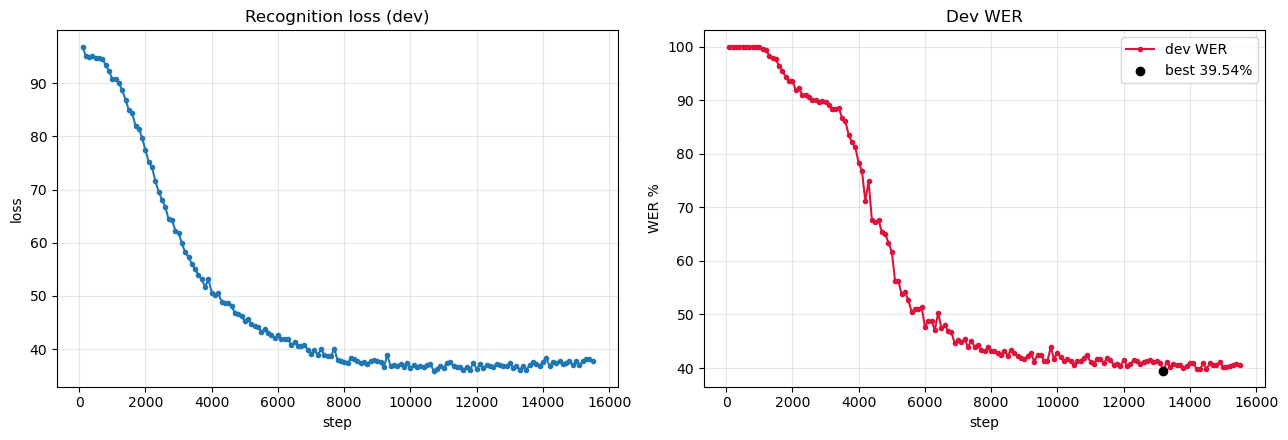

In [6]:
import re

MODEL_DIR = model_dir if 'model_dir' in dir() else "sign_sample"
vpath = Path(MODEL_DIR) / "validations.txt"
assert vpath.exists(), f"{vpath} not found: training has not validated yet"

def _num(pat, line):
    m = re.search(pat, line)
    if not m: return float("nan")
    v = float(m.group(1))
    return float("nan") if v == -1.0 else v

steps, rloss, wer = [], [], []
for line in vpath.read_text(encoding="utf-8").splitlines():
    if not line.startswith("Steps:"): continue
    steps.append(int(re.search(r"Steps:\s*(\d+)", line).group(1)))
    rloss.append(_num(r"Recognition Loss:\s*([-\d.]+)", line))
    wer.append(_num(r"WER\s+([\d.]+)", line))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(steps, rloss, marker="o", ms=3)
ax1.set_title("Recognition loss (dev)")
ax1.set_xlabel("step"); ax1.set_ylabel("loss"); ax1.grid(alpha=0.3)

valid = [(s, w) for s, w in zip(steps, wer) if w == w]
ax2.plot(steps, wer, marker="o", ms=3, color="crimson", label="dev WER")
if valid:
    bs, bw = min(valid, key=lambda t: t[1])
    ax2.scatter([bs], [bw], color="k", zorder=5, label=f"best {bw:.2f}%")
ax2.set_title("Dev WER"); ax2.set_xlabel("step"); ax2.set_ylabel("WER %")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig(Path(MODEL_DIR) / "training_curves.png", dpi=110)
plt.show()

## 6 — Test set evaluation

In [7]:
import glob

MODEL_DIR = model_dir if 'model_dir' in dir() else "sign_sample"
ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.ckpt")))
if not ckpts:
    raise FileNotFoundError("No checkpoint found — training not yet completed")

best_ckpt = ckpts[-1]
print(f"Checkpoint: {best_ckpt}")

output_path = os.path.join(MODEL_DIR, "test_output")
run_test(
    cfg_file="configs/sign.yaml",
    ckpt=best_ckpt,
    output_path=output_path,
)
print("\nTest evaluation complete.")

Checkpoint: ./sign_sample\resume.ckpt


2026-07-08 18:59:55,686 - ------------------------------------------------------------
2026-07-08 18:59:55,697 - [DEV] partition [RECOGNITION] experiment [BW]: 1


COPE:  False


2026-07-08 19:00:03,950 - finished in 8.2533s 
2026-07-08 19:00:03,952 - ************************************************************
2026-07-08 19:00:03,953 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 1
	WER 40.74	(DEL: 15.93,	INS: 2.75,	SUB: 22.07)
2026-07-08 19:00:03,953 - ************************************************************
2026-07-08 19:00:03,954 - ------------------------------------------------------------
2026-07-08 19:00:03,955 - [DEV] partition [RECOGNITION] experiment [BW]: 2
2026-07-08 19:00:13,284 - finished in 9.3291s 
2026-07-08 19:00:13,285 - ************************************************************
2026-07-08 19:00:13,286 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 2
	WER 40.61	(DEL: 15.82,	INS: 2.64,	SUB: 22.15)
2026-07-08 19:00:13,286 - ************************************************************
2026-07-08 19:00:13,288 - ------------------------------------------------------------
2026-07-08 19:00:


Test evaluation complete.
